In [1]:
# data analysis
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pyampute.exploration.md_patterns import mdPatterns
from pyampute.exploration.mcar_statistical_tests import MCARTest
import missingno as msno


# preprocessing
import sklearn.utils.validation
import sys
from scipy import stats
from scipy.stats import shapiro, distributions, loguniform
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, HalvingRandomSearchCV, HalvingGridSearchCV, TunedThresholdClassifierCV, FixedThresholdClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer, MinMaxScaler, KBinsDiscretizer, Binarizer, PolynomialFeatures, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from feature_engine.outliers import Winsorizer
# from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.pipeline import Pipeline
from sklearn import set_config

# Feature Selection
from sklearn.feature_selection import SelectFromModel

# Modeling
from sklearn.linear_model import RidgeClassifier, LogisticRegression, RidgeClassifierCV, LogisticRegressionCV, SGDClassifier, Perceptron, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
import joblib
from sklearn import tree 
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 

# Metrics
from sklearn.metrics import confusion_matrix, recall_score, precision_score, balanced_accuracy_score, ConfusionMatrixDisplay, classification_report, precision_recall_curve, PrecisionRecallDisplay, log_loss, brier_score_loss, roc_curve, roc_auc_score, RocCurveDisplay, det_curve, DetCurveDisplay, fbeta_score, average_precision_score, matthews_corrcoef

# Calibration
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV

# Inspection
from sklearn.inspection import PartialDependenceDisplay

# Custom Functions
from credit_risk_modeling import model_eval
import importlib
importlib.reload(model_eval)

2026-01-15 09:17:28.286 | INFO     | credit_risk_modeling.config:<module>:11 - PROJ_ROOT path is: C:\Users\billy\OneDrive\Documents\Finance_Projects\credit_risk_modeling


<module 'credit_risk_modeling.model_eval' from 'C:\\Users\\billy\\OneDrive\\Documents\\Finance_Projects\\credit_risk_modeling\\credit_risk_modeling\\model_eval.py'>

## Imports

In [2]:
X_train = pd.read_csv(
    filepath_or_buffer = "../data/processed/X_train_tree.csv"
)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22686 entries, 0 to 22685
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   numeric__person_age                          22686 non-null  float64
 1   numeric__person_income                       22686 non-null  float64
 2   numeric__person_emp_length                   22686 non-null  float64
 3   numeric__loan_amnt                           22686 non-null  float64
 4   numeric__loan_int_rate                       22686 non-null  float64
 5   numeric__loan_percent_income                 22686 non-null  float64
 6   numeric__cb_person_cred_hist_length          22686 non-null  float64
 7   categorical__person_home_ownership_MORTGAGE  22686 non-null  float64
 8   categorical__person_home_ownership_OTHER     22686 non-null  float64
 9   categorical__person_home_ownership_OWN       22686 non-null  float64
 10

In [3]:
X_test = pd.read_csv(
    filepath_or_buffer = "../data/processed/X_test_tree.csv"
)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9723 entries, 0 to 9722
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   numeric__person_age                          9723 non-null   float64
 1   numeric__person_income                       9723 non-null   float64
 2   numeric__person_emp_length                   9723 non-null   float64
 3   numeric__loan_amnt                           9723 non-null   float64
 4   numeric__loan_int_rate                       9723 non-null   float64
 5   numeric__loan_percent_income                 9723 non-null   float64
 6   numeric__cb_person_cred_hist_length          9723 non-null   float64
 7   categorical__person_home_ownership_MORTGAGE  9723 non-null   float64
 8   categorical__person_home_ownership_OTHER     9723 non-null   float64
 9   categorical__person_home_ownership_OWN       9723 non-null   float64
 10  

In [4]:
y_train = pd.read_csv(
    filepath_or_buffer = "../data/interim/y_train.csv"
)
y_train = y_train.values.ravel()

In [5]:
y_test = pd.read_csv(
    filepath_or_buffer = "../data/interim/y_test.csv"
)
y_test.head(1)
y_test = y_test.values.ravel()

## Compare Models

Not accouting for feature selection (unless), class imbalance, or hyperparameter tuning

In [9]:
untuned_models = [
    DummyClassifier(strategy="most_frequent"),
    tree.DecisionTreeClassifier(
        random_state = 42,
    ), # no sampling 
    AdaBoostClassifier(
        random_state=42
    ), # default estimator is DecisionTreeClassifier, default no sampling
    XGBClassifier(
        reg_lambda=0,
        reg_alpha=0,
        random_state=42
    ), # default embedded l2 regularization, default includes no sampling (but sampling is possible for both samples and features - would be pasting + subspacing so replacement=None)
    LGBMClassifier(
    objective='binary',
    reg_alpha = 0,
    reg_lambda = 0,
    random_state=42
    ), # default embedded l2 regularization, default includes no sampling (but sampling is possible for both samples and features - would be pasting + subspacing so replacement=None)
    HistGradientBoostingClassifier(
        l2_regularization= 0,
        random_state=42
    ), # no regularization, default no subsampling but can be turned on
    GradientBoostingClassifier(
        subsample = 1.0,
        random_state=42
    ), # default no subsampling regularization but Pasting can be turned on
    RandomForestClassifier(
        n_jobs=-1,
        random_state=42
    ), # default Bagging, Subspacing
    ExtraTreesClassifier(
        n_jobs=-1,
        random_state=42
    ), # default all samples but Bagging can be turned on, Subspacing for features
    BaggingClassifier(estimator=tree.DecisionTreeClassifier(
        random_state=42), 
        n_estimators=50, 
        bootstrap=True, 
        max_samples=1.0,
        max_features=1.0, 
        random_state=42),
    #VotingClassifier(
    #    estimators= [('lgbm', LGBMClassifier(n_jobs=-1, random_state=42)), ('xgb', XGBClassifier(n_jobs=-1, random_state=42)), ('hgb', HistGradientBoostingClassifier(random_state=42)), ('rf', RandomForestClassifier(n_jobs=-1, random_state=42))],
    #    voting='soft',
    #    n_jobs=-1
    # ), # technically not tree based model
    #StackingClassifier(
    #    estimators= [('lgbm', LGBMClassifier(n_jobs=-1,random_state=42)), ('xgb', XGBClassifier(n_jobs=-1, random_state=42)), ('hgb', HistGradientBoostingClassifier(random_state=42)), ('rf', RandomForestClassifier(n_jobs=-1, random_state=42))],
    #    final_estimator= LGBMClassifier(random_state=42),
    #    n_jobs=-1
    # ), # technically not tree based model
    #StackingClassifier(
    #    estimators= [('lgbm', LGBMClassifier(n_jobs=-1,random_state=42)), ('xgb', XGBClassifier(n_jobs=-1, random_state=42)), ('hgb', HistGradientBoostingClassifier(random_state=42)), ('rf', RandomForestClassifier(n_jobs=-1, random_state=42))],
    #    final_estimator= StackingClassifier(
    #        estimators= [('lgbm', LGBMClassifier(n_jobs=-1,random_state=42)), ('xgb', XGBClassifier(n_jobs=-1, random_state=42)), ('hgb', HistGradientBoostingClassifier(random_state=42)), ('rf', RandomForestClassifier(n_jobs=-1, random_state=42))],
    #        final_estimator= LGBMClassifier(n_jobs=-1, random_state=42),
    #        n_jobs=-1
    #    ), # technically not tree based model
    #    n_jobs=-1
    #) # multiple layer
]

In [10]:

untuned_model_performance, fitted_models = model_eval.comparing_models(untuned_models, X_train, y_train, X_test, y_test)

[LightGBM] [Info] Number of positive: 4962, number of negative: 17724
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1095
[LightGBM] [Info] Number of data points in the train set: 22686, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218725 -> initscore=-1.273111
[LightGBM] [Info] Start training from score -1.273111


In [11]:
untuned_model_performance

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef
4,"LGBMClassifier (n_jobs=None, class_weight=None)",0.947471,0.905422,0.187019,0.051526,0.811737
3,XGBClassifier (n_jobs=None),0.946807,0.904673,0.189538,0.052129,0.805611
5,HistGradientBoostingClassifier (class_weight=N...,0.943899,0.900761,0.191137,0.052506,0.810424
7,"RandomForestClassifier (n_jobs=-1, class_weigh...",0.934425,0.887971,0.241671,0.056657,0.804788
9,BaggingClassifier (n_jobs=None),0.929023,0.884195,0.316043,0.056605,0.802633
6,GradientBoostingClassifier,0.928608,0.877217,0.228877,0.062940,0.778233
8,"ExtraTreesClassifier (n_jobs=-1, class_weight=...",0.920514,0.864862,0.282156,0.066162,0.772874
2,AdaBoostClassifier,0.886140,0.757602,0.501694,0.158031,0.604051
1,DecisionTreeClassifier (class_weight=None),0.849316,0.617582,4.003615,0.111077,0.683030
0,DummyClassifier,0.500000,0.218657,7.881190,0.218657,0.000000


In [12]:
untuned_model_performance['untuned_model'] = 1

## Hyperparameter Tuning, Class Imbalance, Feature Selection

### LGBMClassifier

In [13]:
lgbm = LGBMClassifier(
    objective='binary',
    unbalance = True,
    random_state=42
    )

In [14]:
lgbm_param_dist = {
    "num_leaves": stats.randint(16, 256),
    "min_data_in_leaf": stats.randint(10, 500),
    "max_depth": stats.randint(3, 10),
    "learning_rate": stats.loguniform(0.01, 0.2),
    "n_estimators": stats.randint(200, 1000),
    "feature_fraction": stats.uniform(0.6, 0.4),
    "bagging_fraction": stats.uniform(0.6, 0.4),
    "bagging_freq": stats.randint(1, 6),
    "lambda_l1": stats.loguniform(1e-3, 1),
    "lambda_l2" :stats.loguniform(1e-3, 1),
}

In [15]:
lgbm_tuned = HalvingRandomSearchCV(
estimator = lgbm,
param_distributions=lgbm_param_dist,
scoring = 'roc_auc',
n_jobs=-1,
random_state=42)

### XGBClassifier

In [16]:
xgbm = XGBClassifier(
    objective='binary:logistic',
    unbalance = True,
    random_state=42
    )

In [17]:
xgbm_param_dist = {
    "max_depth": stats.randint(3, 10),
    "min_child_weight": stats.loguniform(1e-1, 1e2),
    "gamma": stats.loguniform(1e-3, 1),
    "reg_alpha": stats.loguniform(1e-3, 10),
    "reg_lambda": stats.loguniform(1e-3, 10),
    "subsample": stats.uniform(0.5, 0.5),
    "colsample_bytree": stats.uniform(0.5, 0.5),
    "learning_rate": stats.loguniform(0.01, 0.3),
    "n_estimators": stats.randint(200, 1000),
}

In [18]:
xgbm_tuned = HalvingRandomSearchCV(
estimator = xgbm,
param_distributions=xgbm_param_dist,
scoring = 'roc_auc',
n_jobs=-1,
random_state=42)

### HistGradientBoosting

In [19]:
hgb = HistGradientBoostingClassifier(
    random_state=42, 
    class_weight='balanced')

In [20]:
hgb_param_dist = {
    "max_depth": stats.randint(3, 10),
    "max_leaf_nodes": stats.randint(15, 255),
    "min_samples_leaf": stats.randint(10, 200),
    "learning_rate": stats.loguniform(0.01, 0.2),
    "max_iter": stats.randint(200, 1000),
    "l2_regularization": stats.loguniform(1e-3, 1),
    "max_bins": stats.randint(64, 255),
}

In [21]:
hgb_tuned = HalvingRandomSearchCV(
estimator = hgb,
param_distributions=hgb_param_dist,
scoring = 'roc_auc',
n_jobs=-1,
random_state=42)

### Random Forest

In [22]:
rf = RandomForestClassifier(
    n_jobs=-1, 
    random_state=42, 
    class_weight='balanced')

In [23]:
rf_param_dist = {
    "max_depth": stats.randint(3, 20),
    "min_samples_split": stats.randint(2, 20),
    "min_samples_leaf": stats.randint(1, 10),
    "n_estimators": stats.randint(200, 1000),
    "max_features": stats.uniform(0.4, 0.6),
    "bootstrap": [True, False],
    "max_leaf_nodes": stats.randint(10, 200),
}

In [24]:
rf_tuned = HalvingRandomSearchCV(
estimator = rf,
param_distributions=rf_param_dist,
scoring = 'roc_auc',
n_jobs=-1,
random_state=42)

### Manually tuning

In [25]:
manually_tuned_models = [
    lgbm_tuned,
    xgbm_tuned,
    hgb_tuned,
    rf_tuned
]

In [26]:
manual_tuned_model_performance, fitted_models_manual = model_eval.comparing_manually_tuned_models(manually_tuned_models, X_train, y_train, X_test, y_test)

c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... 0.5 0.5 0.5]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.79139317 0.79637366 0.78622981]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.83326694 0.85708142 0.85973653]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeli

[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] feature_fraction is set=0.8060944219456844, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8060944219456844
[LightGBM] [Warning] lambda_l1 is set=0.8304835754879606, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.8304835754879606
[LightGBM] [Warning] lambda_l2 is set=0.06394494035654308, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.06394494035654308
[LightGBM] [Warning] bagging_fraction is set=0.9587153639624048, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9587153639624048
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] feature_fraction is set=0.8060944219456844, colsample_byt

c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.53113636 0.78666667 0.5       ]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.79550367 0.80713381 0.79900071]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.87173076 0.86908452 0.8774884 ]
  warnings.warn(
c:\Use

In [38]:
manual_tuned_model_performance['untuned_model'] = 0

In [39]:
manual_tuned_model_performance = manual_tuned_model_performance.sort_values(
    ascending= False,
    by= 'roc_auc'
)

## Probability Calibration

In [40]:
model_performances = model_eval.combine_model_performance(untuned_model_performance, manual_tuned_model_performance)

In [41]:
model_performances

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef,untuned_model
4,"LGBMClassifier (n_jobs=None, class_weight=None)",0.947471,0.905422,0.187019,0.051526,0.811737,1
3,XGBClassifier (n_jobs=None),0.946807,0.904673,0.189538,0.052129,0.805611,1
5,HistGradientBoostingClassifier (class_weight=N...,0.943899,0.900761,0.191137,0.052506,0.810424,1
7,"RandomForestClassifier (n_jobs=-1, class_weigh...",0.934425,0.887971,0.241671,0.056657,0.804788,1
9,BaggingClassifier (n_jobs=None),0.929023,0.884195,0.316043,0.056605,0.802633,1
6,GradientBoostingClassifier,0.928608,0.877217,0.228877,0.062940,0.778233,1
8,"ExtraTreesClassifier (n_jobs=-1, class_weight=...",0.920514,0.864862,0.282156,0.066162,0.772874,1
2,AdaBoostClassifier,0.886140,0.757602,0.501694,0.158031,0.604051,1
1,DecisionTreeClassifier (class_weight=None),0.849316,0.617582,4.003615,0.111077,0.683030,1
0,DummyClassifier,0.500000,0.218657,7.881190,0.218657,0.000000,1


Log loss (sigmoid): 0.1923
Brier score (sigmoid): 0.0520
Log loss (isotonic): 0.1842
Brier score (isotonic): 0.0514


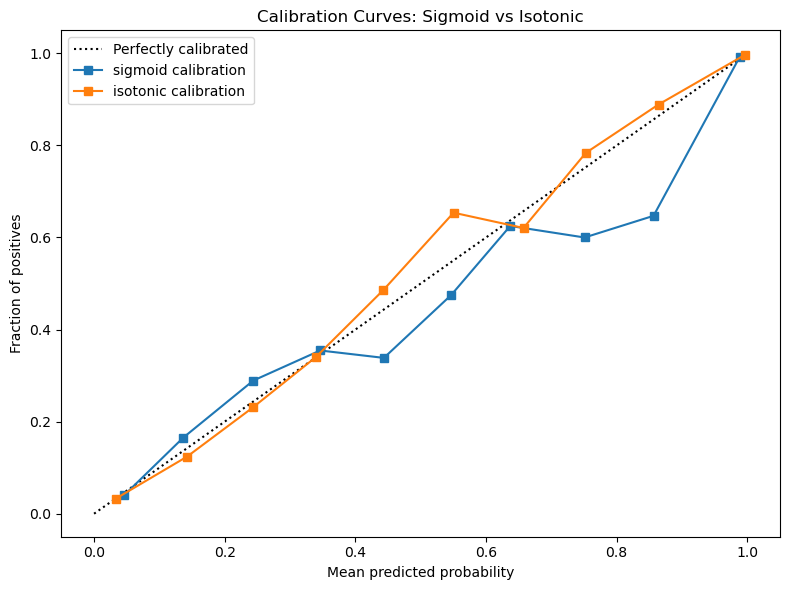

In [42]:
calibrated_models = model_eval.evaluate_calibration(model_performances, fitted_models, X_train, y_train, X_test, y_test)

In [43]:
calibrated_models

{'sigmoid': CalibratedClassifierCV(estimator=LGBMClassifier(objective='binary',
                                                 random_state=42, reg_alpha=0,
                                                 reg_lambda=0),
                        n_jobs=-1),
 'isotonic': CalibratedClassifierCV(estimator=LGBMClassifier(objective='binary',
                                                 random_state=42, reg_alpha=0,
                                                 reg_lambda=0),
                        method='isotonic', n_jobs=-1)}

In [44]:
top_performing_calibrated_model = calibrated_models['isotonic']

## Decision Threshold Comparison

Classification Report (Base Estimator):
               precision    recall  f1-score   support

       False       0.93      1.00      0.96      7597
        True       0.98      0.73      0.84      2126

    accuracy                           0.94      9723
   macro avg       0.95      0.86      0.90      9723
weighted avg       0.94      0.94      0.93      9723

Business Cost (Base Estimator): $5718000


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Classification Report (Tuned Estimator):
               precision    recall  f1-score   support

       False       0.00      0.00      0.00      7597
        True       0.22      1.00      0.36      2126

    accuracy                           0.22      9723
   macro avg       0.11      0.50      0.18      9723
weighted avg       0.05      0.22      0.08      9723

Business Cost (Tuned Estimator): $3798500


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.8 and will be removed in 1.10. Please use `y_score` instead.
  warnings.warn(


Classification Report (Chosen Threshold):
               precision    recall  f1-score   support

       False       0.98      0.56      0.72      7597
        True       0.38      0.96      0.55      2126

    accuracy                           0.65      9723
   macro avg       0.68      0.76      0.63      9723
weighted avg       0.85      0.65      0.68      9723

Business Cost (Chosen Threshold): $2406000


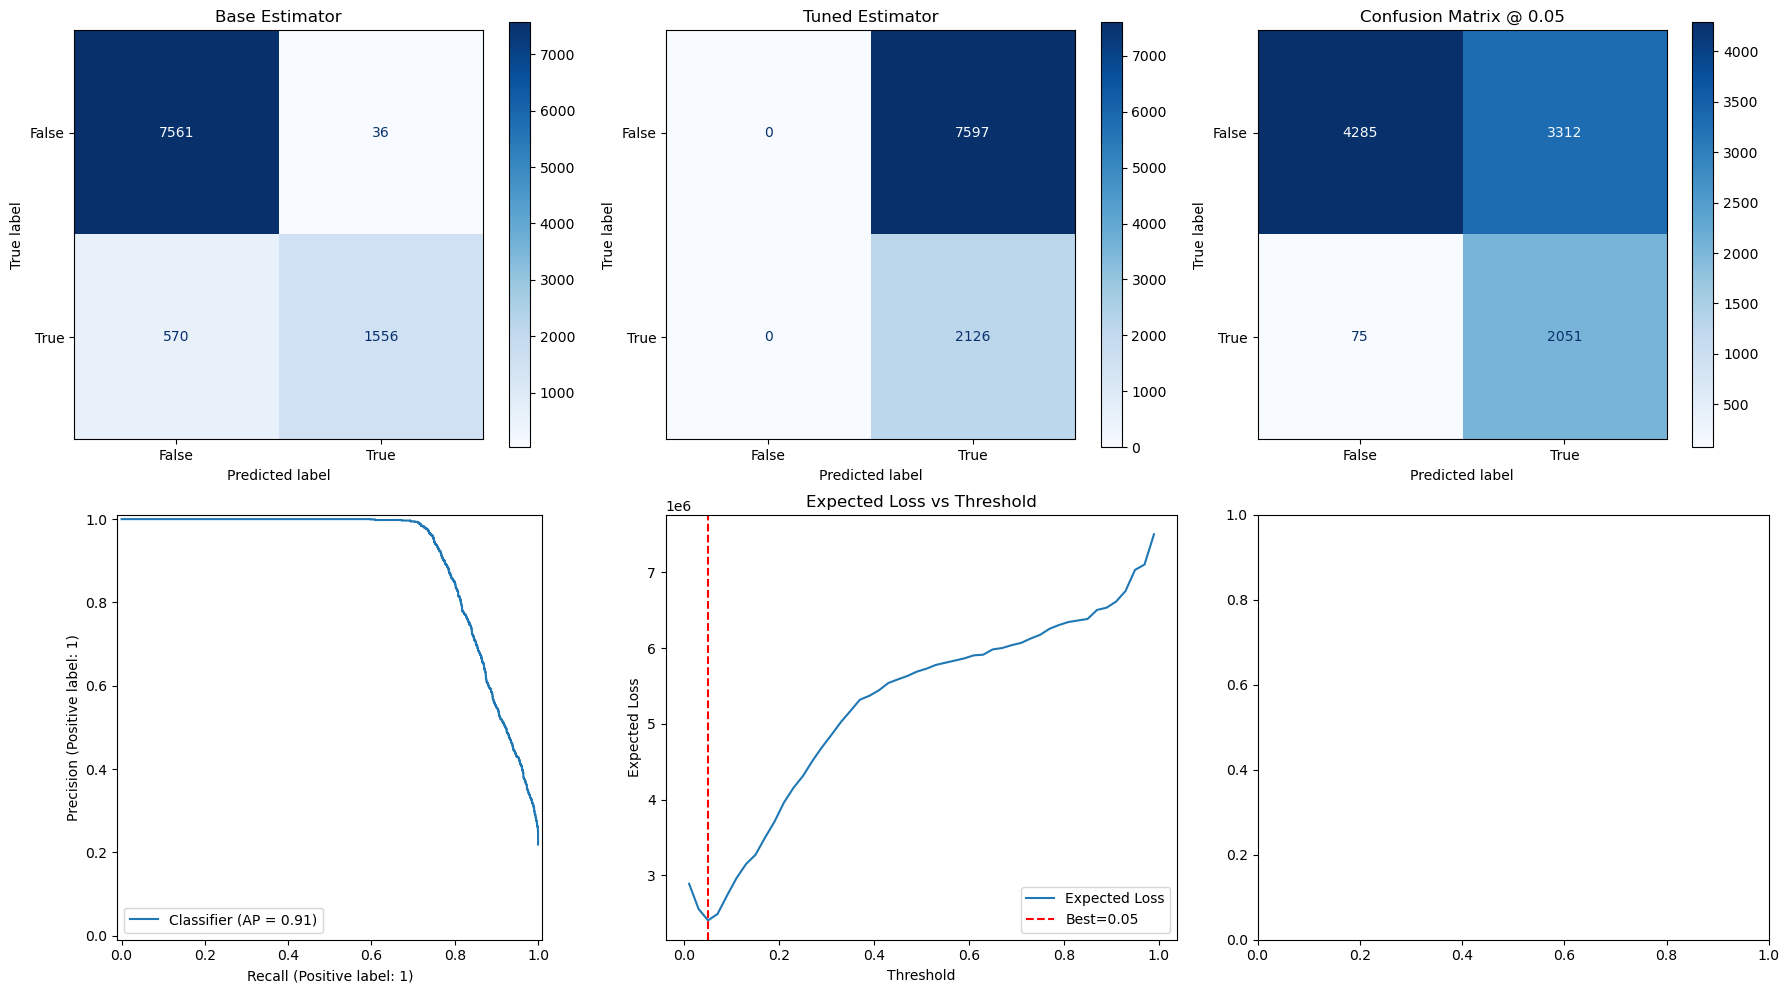

In [45]:
final_model_eval = model_eval.decision_threshold_comparisons(top_performing_calibrated_model, X_train, y_train, X_test, y_test)

In [46]:
best_tree_model = final_model_eval['chosen_estimator']

In [47]:
best_tree_model

,"estimator estimator: estimator instanceThe binary classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.","CalibratedCla...c', n_jobs=-1)"
,"threshold threshold: {""auto""} or float, default=""auto""The decision threshold to use when converting posterior probability estimates(i.e. output of `predict_proba`) or decision scores (i.e. output of`decision_function`) into a class label. When `""auto""`, the threshold is setto 0.5 if `predict_proba` is used as `response_method`, otherwise it is set to0 (i.e. the default threshold for `decision_function`).",0.05
,"pos_label pos_label: int, float, bool or str, default=NoneThe label of the positive class. Used to process the output of the`response_method` method. When `pos_label=None`, if `y_true` is in `{-1, 1}` or`{0, 1}`, `pos_label` is set to 1, otherwise an error will be raised.",None
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'binary'


In [48]:
joblib.dump(best_tree_model, "../models/best_tree_model.pkl")

['../models/best_tree_model.pkl']